# Human-Synthetic Comparision Spam Detection Using BLSTM with CNN Layers

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Bidirectional, Dense, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Attention
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Download stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
# Load dataset (make sure you have the 'SMSSpamCollection' file in the directory)
data = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=["label", "message"])

# Display first few rows to inspect the dataset
data.head()

# Text preprocessing function
def preprocess_text(text):
    text = re.sub(r'\W', ' ', text)  # Remove non-word characters
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    text = text.lower()  # Convert to lowercase
    return text

# Apply preprocessing
data['message'] = data['message'].apply(preprocess_text)

# Convert labels into numeric values (ham=0, spam=1)
data['label'] = data['label'].map({'ham': 0, 'spam': 1})

# Split data into training and test sets
X = data['message']
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
# Tokenize the text data
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

# Convert text into sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad the sequences to ensure uniform length
max_length = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)


In [4]:
# Build the model using Bidirectional LSTM and Conv1D (No Attention Layer)
model = Sequential()

# Embedding layer for text vectorization
model.add(Embedding(input_dim=5000, output_dim=128, input_length=max_length))

# Bidirectional LSTM Layer
model.add(Bidirectional(LSTM(64, return_sequences=True)))

# Add Convolutional Layer for feature extraction
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))

# MaxPooling to reduce dimensionality
model.add(MaxPooling1D(pool_size=2))

# Global Max Pooling to get fixed-length output
model.add(GlobalMaxPooling1D())

# Fully connected layer for classification
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model summary to inspect the layers
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the model
history = model.fit(X_train_pad, y_train, epochs=5, batch_size=64, validation_data=(X_test_pad, y_test))


Epoch 1/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 32s 305ms/step - accuracy: 0.8817 - loss: 0.3728 - val_accuracy: 0.9865 - val_loss: 0.0519
Epoch 2/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 266ms/step - accuracy: 0.9844 - loss: 0.0537 - val_accuracy: 0.9901 - val_loss: 0.0406
Epoch 3/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 283ms/step - accuracy: 0.9957 - loss: 0.0175 - val_accuracy: 0.9910 - val_loss: 0.0423
Epoch 4/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 298ms/step - accuracy: 0.9992 - loss: 0.0045 - val_accuracy: 0.9910 - val_loss: 0.0496
Epoch 5/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 39s 269ms/step - accuracy: 0.9987 - loss: 0.0069 - val_accuracy: 0.9901 - val_loss: 0.0536


In [6]:
# Evaluate the model
y_pred = model.predict(X_test_pad)
y_pred = (y_pred > 0.5)

# Print classification report and accuracy score
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))


35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.97      0.96      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115

Accuracy Score:
0.9901345291479821


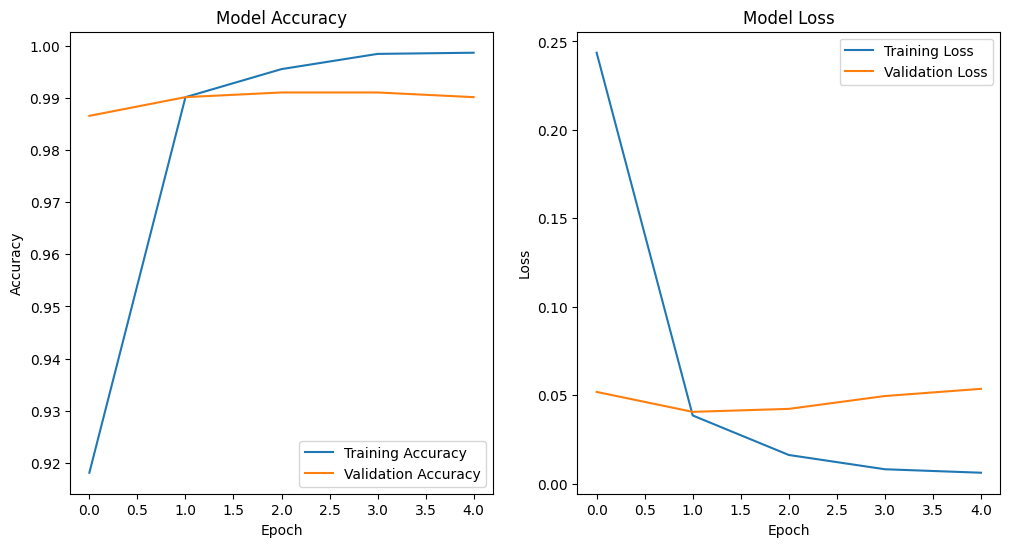

In [7]:
# Plot training history (accuracy and loss)
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [8]:
# Import necessary libraries for text preprocessing
import numpy as np

# Test function to predict if a message is spam or ham
def predict_message(message, tokenizer, model, max_len=50):
    # Step 1: Preprocess the text message
    # Tokenize the text
    message_seq = tokenizer.texts_to_sequences([message])

    # Step 2: Pad the sequences to ensure uniform input size
    message_pad = pad_sequences(message_seq, maxlen=max_len, padding='post', truncating='post')

    # Step 3: Make the prediction
    prediction = model.predict(message_pad)

    # Step 4: Output the prediction result
    if prediction[0] > 0.5:
        return "Spam"
    else:
        return "Ham"


In [9]:
# Test with a Spam message
spam_message = "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"

result_spam = predict_message(spam_message, tokenizer, model)
print(f"Message: {spam_message}\nPrediction: {result_spam}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step
Message: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Prediction: Spam


In [10]:
# Test with a Ham message
ham_message = "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."

result_ham = predict_message(ham_message, tokenizer, model)
print(f"Message: {ham_message}\nPrediction: {result_ham}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Message: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Prediction: Ham


Explanation of the Code:

Imports and Setup:

Libraries such as pandas, nltk, and keras are imported to handle data, preprocessing, and model building.

stopwords from NLTK is used to remove common words that don’t contribute much to text classification.

The dataset is loaded from the file SMSSpamCollection and preprocessed by removing non-alphabetical characters, converting to lowercase, and normalizing spaces.

Data Preprocessing:

The text is tokenized, and sequences are padded to ensure they all have the same length.

Labels (ham and spam) are encoded into binary values (0 for ham and 1 for spam).

Model Architecture:

Embedding Layer: Transforms the input text into word embeddings.

Bidirectional LSTM Layer: The LSTM layer processes text data sequentially, capturing context from both directions (previous and future).

Convolutional Layer (CNN): A 1D Convolutional layer is added to extract important local features (n-grams) from the text.

Attention Layer: This layer is used to focus on the most important words or sequences in the input, improving model performance by assigning higher attention scores to more informative tokens.

Global Max Pooling: Reduces the dimensions of the feature map to ensure a fixed-length output for classification.

Fully Connected Layer: The final layer consists of a dense layer with sigmoid activation to output the binary class label (spam or ham).

Model Training:

The model is compiled with Adam optimizer and binary cross-entropy loss, then trained for 5 epochs.

Evaluation:

The model is evaluated on the test set, and the performance is reported using classification metrics like accuracy and F1-score.

Visualization:

The training and validation accuracy/loss curves are plotted to visualize the model's performance during training.

Important Notes:

Dataset: Make sure that the SMSSpamCollection file is in the correct directory, and it’s properly formatted (with tab-separated label and message columns).

Model Complexity: The architecture includes both LSTM and CNN layers, which allows the model to learn both sequential patterns and local features from the text.

Attention Layer: The attention mechanism helps the model focus on the most relevant parts of the text when making decisions (especially useful for complex text classification tasks).

# Synthetic Dataset

In [11]:
# Load synthetic dataset (with header)
data_syn = pd.read_csv('Merged_Cleaned_Synthetic_SMSSpamCollection.csv', sep='\t')

# Display first few rows to inspect the dataset
data_syn.head()

# Text preprocessing function
def preprocess_text(text):
    text = re.sub(r'\W', ' ', str(text))  # Remove non-word characters
    text = re.sub(r'\s+', ' ', text)      # Remove extra spaces
    text = text.lower()                   # Convert to lowercase
    return text

# Apply preprocessing
data_syn['message'] = data_syn['message'].apply(preprocess_text)

# Convert labels into numeric values (ham=0, spam=1)
data_syn['label'] = data_syn['label'].map({'ham': 0, 'spam': 1})

# Split synthetic data into training and test sets
X_syn = data_syn['message']
y_syn = data_syn['label']
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(X_syn, y_syn, test_size=0.2, random_state=42)


In [12]:
# Tokenize the synthetic text data
tokenizer_syn = Tokenizer(num_words=5000)
tokenizer_syn.fit_on_texts(X_train_syn)

# Convert synthetic text into sequences
X_train_seq_syn = tokenizer_syn.texts_to_sequences(X_train_syn)
X_test_seq_syn = tokenizer_syn.texts_to_sequences(X_test_syn)

# Pad the sequences to ensure uniform length
max_length_syn = 100
X_train_pad_syn = pad_sequences(X_train_seq_syn, maxlen=max_length_syn)
X_test_pad_syn = pad_sequences(X_test_seq_syn, maxlen=max_length_syn)


In [13]:
# Build the model for synthetic dataset using Bidirectional LSTM and Conv1D
model_syn = Sequential()

# Embedding layer for text vectorization
model_syn.add(Embedding(input_dim=5000, output_dim=128, input_length=max_length_syn))

# Bidirectional LSTM Layer
model_syn.add(Bidirectional(LSTM(64, return_sequences=True)))

# Add Convolutional Layer for feature extraction
model_syn.add(Conv1D(filters=64, kernel_size=3, activation='relu'))

# MaxPooling to reduce dimensionality
model_syn.add(MaxPooling1D(pool_size=2))

# Global Max Pooling to get fixed-length output
model_syn.add(GlobalMaxPooling1D())

# Fully connected layer for classification
model_syn.add(Dense(1, activation='sigmoid'))

# Compile the model
model_syn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model summary to inspect the layers
model_syn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train the model on synthetic dataset
history_syn = model_syn.fit(
    X_train_pad_syn,
    y_train_syn,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_pad_syn, y_test_syn)
)


Epoch 1/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 22s 298ms/step - accuracy: 0.6833 - loss: 0.5852 - val_accuracy: 0.9218 - val_loss: 0.2226
Epoch 2/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 282ms/step - accuracy: 0.9396 - loss: 0.1680 - val_accuracy: 0.9359 - val_loss: 0.1884
Epoch 3/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 22s 313ms/step - accuracy: 0.9804 - loss: 0.0726 - val_accuracy: 0.9403 - val_loss: 0.1955
Epoch 4/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 269ms/step - accuracy: 0.9852 - loss: 0.0494 - val_accuracy: 0.9359 - val_loss: 0.2698
Epoch 5/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 277ms/step - accuracy: 0.9911 - loss: 0.0257 - val_accuracy: 0.9327 - val_loss: 0.3288


In [15]:
# Evaluate the model on synthetic dataset
y_pred_syn = model_syn.predict(X_test_pad_syn)
y_pred_syn = (y_pred_syn > 0.5)

# Print classification report and accuracy score for synthetic
print("Synthetic Dataset Classification Report:")
print(classification_report(y_test_syn, y_pred_syn))

print("Synthetic Dataset Accuracy Score:")
print(accuracy_score(y_test_syn, y_pred_syn))


29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step
Synthetic Dataset Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       614
           1       0.92      0.88      0.90       307

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921

Synthetic Dataset Accuracy Score:
0.9326818675352877


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

# Original dataset predictions and metrics
y_pred_orig = model.predict(X_test_pad)
y_pred_orig = (y_pred_orig > 0.5).astype(int)

orig_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_orig),
    'Precision': precision_score(y_test, y_pred_orig),
    'Recall': recall_score(y_test, y_pred_orig),
    'F1 Score': f1_score(y_test, y_pred_orig)
}

print("Original Dataset Classification Report:")
print(classification_report(y_test, y_pred_orig))


# Synthetic dataset predictions and metrics
y_pred_syn = model_syn.predict(X_test_pad_syn)
y_pred_syn = (y_pred_syn > 0.5).astype(int)

syn_metrics = {
    'Accuracy': accuracy_score(y_test_syn, y_pred_syn),
    'Precision': precision_score(y_test_syn, y_pred_syn),
    'Recall': recall_score(y_test_syn, y_pred_syn),
    'F1 Score': f1_score(y_test_syn, y_pred_syn)
}

print("Synthetic Dataset Classification Report:")
print(classification_report(y_test_syn, y_pred_syn))


# Combine into a DataFrame for comparison
comparison_blstm_df = pd.DataFrame({
    'BLSTM+CNN_Original': orig_metrics,
    'BLSTM+CNN_Synthetic': syn_metrics
}).round(4)

print("🔍 BLSTM+CNN Model Performance Comparison:")
display(comparison_blstm_df)


35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step
Original Dataset Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.97      0.96      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
Synthetic Dataset Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       614
           1       0.92      0.88      0.90       307

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921

🔍 BLSTM+CNN Model Performance Comparison:


,BLSTM+CNN_Original,BLSTM+CNN_Synthetic
Accuracy,0.9901,0.9327
Precision,0.9662,0.9153
Recall,0.9597,0.8795
F1 Score,0.9630,0.8970


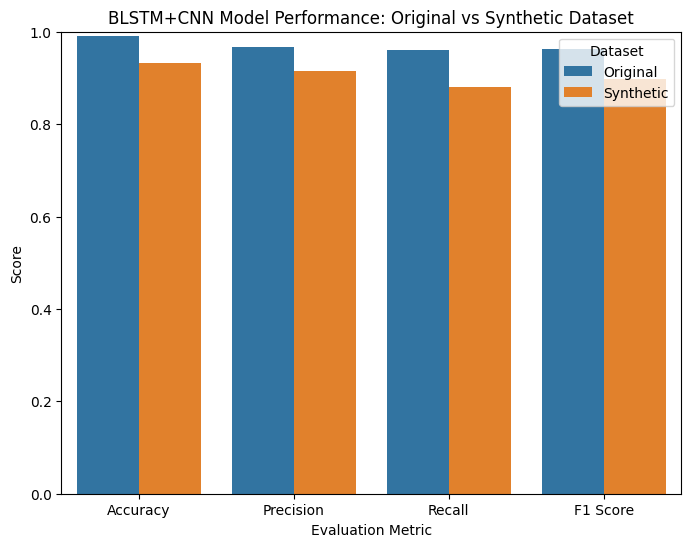

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
original_scores = [orig_metrics[m] for m in metrics]
synthetic_scores = [syn_metrics[m] for m in metrics]

# Create a DataFrame suitable for seaborn
plot_df = pd.DataFrame({
    'Metric': metrics * 2,
    'Score': original_scores + synthetic_scores,
    'Dataset': ['Original'] * len(metrics) + ['Synthetic'] * len(metrics)
})

# Plot grouped barplot
plt.figure(figsize=(8, 6))
sns.barplot(x='Metric', y='Score', hue='Dataset', data=plot_df)
plt.ylim(0, 1)
plt.title('BLSTM+CNN Model Performance: Original vs Synthetic Dataset')
plt.ylabel('Score')
plt.xlabel('Evaluation Metric')
plt.legend(title='Dataset')
plt.show()


## Synthetic Model on Original Data

In [18]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Step 1: Tokenize original test messages with synthetic tokenizer
X_test_seq_on_syn = tokenizer_syn.texts_to_sequences(X_test)
X_test_pad_on_syn = pad_sequences(X_test_seq_on_syn, maxlen=max_length)  # use the same max_length as synthetic model

# Step 2: Predict with synthetic-trained model
y_pred_prob_on_orig = model_syn.predict(X_test_pad_on_syn)
y_pred_on_orig = (y_pred_prob_on_orig > 0.5).astype(int)

# Step 3: Evaluate
print("Synthetic Model Tested on Original Dataset:")
print("Accuracy:", accuracy_score(y_test, y_pred_on_orig))
print("Precision:", precision_score(y_test, y_pred_on_orig))
print("Recall:", recall_score(y_test, y_pred_on_orig))
print("F1 Score:", f1_score(y_test, y_pred_on_orig))
print("\nClassification Report:\n", classification_report(y_test, y_pred_on_orig, target_names=["Ham", "Spam"]))


35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step
Synthetic Model Tested on Original Dataset:
Accuracy: 0.8789237668161435
Precision: 0.5339805825242718
Recall: 0.738255033557047
F1 Score: 0.6197183098591549

Classification Report:
               precision    recall  f1-score   support

         Ham       0.96      0.90      0.93       966
        Spam       0.53      0.74      0.62       149

    accuracy                           0.88      1115
   macro avg       0.75      0.82      0.77      1115
weighted avg       0.90      0.88      0.89      1115



35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step
Original Dataset Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.97      0.96      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
Synthetic Dataset Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       614
           1       0.92      0.88      0.90       307

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
Synthetic Model Tested on Original Dataset:
              precision    recall  f1-score   support

         Ham       0.96      0.90      0.93   

,Original Model on Original Data,Synthetic Model on Synthetic Data,Synthetic Model on Original Data
Accuracy,0.9901,0.9327,0.8789
Precision,0.9662,0.9153,0.5340
Recall,0.9597,0.8795,0.7383
F1 Score,0.9630,0.8970,0.6197


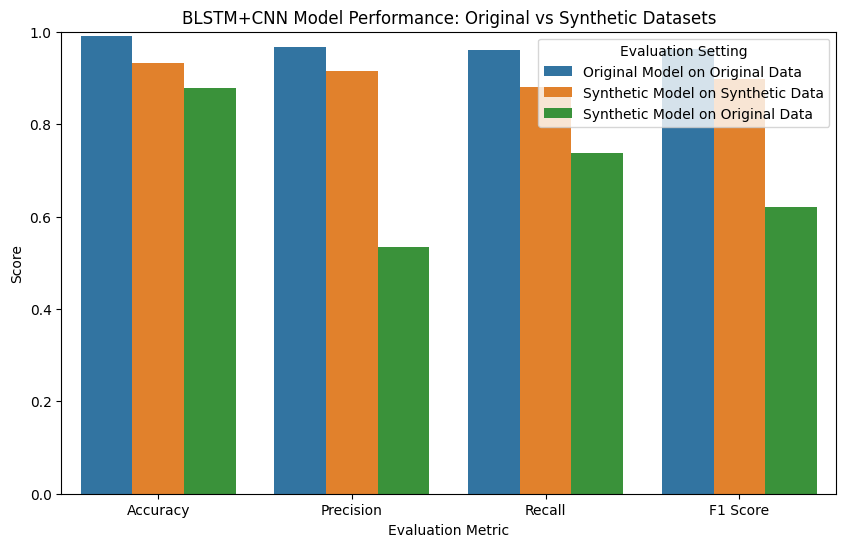

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tensorflow.keras.preprocessing.sequence import pad_sequences

# === Step 1: Evaluate Original Model on Original Test Set ===
y_pred_orig = model.predict(X_test_pad)
y_pred_orig = (y_pred_orig > 0.5).astype(int)

orig_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_orig),
    'Precision': precision_score(y_test, y_pred_orig),
    'Recall': recall_score(y_test, y_pred_orig),
    'F1 Score': f1_score(y_test, y_pred_orig)
}

print("Original Dataset Classification Report:")
print(classification_report(y_test, y_pred_orig))

# === Step 2: Evaluate Synthetic Model on Synthetic Test Set ===
y_pred_syn = model_syn.predict(X_test_pad_syn)
y_pred_syn = (y_pred_syn > 0.5).astype(int)

syn_metrics = {
    'Accuracy': accuracy_score(y_test_syn, y_pred_syn),
    'Precision': precision_score(y_test_syn, y_pred_syn),
    'Recall': recall_score(y_test_syn, y_pred_syn),
    'F1 Score': f1_score(y_test_syn, y_pred_syn)
}

print("Synthetic Dataset Classification Report:")
print(classification_report(y_test_syn, y_pred_syn))

# === Step 3: Test Synthetic Model on Original Test Set ===
# Tokenize and pad original test messages using synthetic tokenizer and max_length
X_test_seq_on_syn = tokenizer_syn.texts_to_sequences(X_test)
X_test_pad_on_syn = pad_sequences(X_test_seq_on_syn, maxlen=max_length)

y_pred_prob_on_orig = model_syn.predict(X_test_pad_on_syn)
y_pred_on_orig = (y_pred_prob_on_orig > 0.5).astype(int)

syn_on_orig_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_on_orig),
    'Precision': precision_score(y_test, y_pred_on_orig),
    'Recall': recall_score(y_test, y_pred_on_orig),
    'F1 Score': f1_score(y_test, y_pred_on_orig)
}

print("Synthetic Model Tested on Original Dataset:")
print(classification_report(y_test, y_pred_on_orig, target_names=["Ham", "Spam"]))

# === Step 4: Combine all metrics into one DataFrame ===
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

comparison_df = pd.DataFrame({
    'Original Model on Original Data': [orig_metrics[m] for m in metrics],
    'Synthetic Model on Synthetic Data': [syn_metrics[m] for m in metrics],
    'Synthetic Model on Original Data': [syn_on_orig_metrics[m] for m in metrics]
}, index=metrics).round(4)

print("\n🔍 BLSTM+CNN Model Performance Comparison:")
display(comparison_df)

# === Step 5: Plot grouped bar chart ===
plot_df = comparison_df.reset_index().melt(id_vars='index', var_name='Evaluation Setting', value_name='Score')
plot_df.rename(columns={'index': 'Metric'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='Metric', y='Score', hue='Evaluation Setting')
plt.ylim(0, 1)
plt.title('BLSTM+CNN Model Performance: Original vs Synthetic Datasets')
plt.ylabel('Score')
plt.xlabel('Evaluation Metric')
plt.legend(title='Evaluation Setting')
plt.show()
